In [1]:
import sys
import torch

print("Python:", sys.version)
print("Executable:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Executable: d:\Historical Image Restoration\.venv\Scripts\python.exe
PyTorch: 2.14.0+cpu
CUDA available: False


In [1]:
from datasets import load_dataset

dataset = load_dataset("joshuachin/openphoto-restore-dataset")

print(dataset)

data/train-00007-of-00009.parquet: reconstructing file:   0%|          |  0.00B /  443MB            

data/train-00007-of-00009.parquet: downloading bytes:           |  0.00B            

d:\Historical Image Restoration\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sharo\.cache\huggingface\hub\datasets--joshuachin--openphoto-restore-dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00008-of-00009.parquet: reconstructing file:   0%|          |  0.00B /  440MB            

data/train-00008-of-00009.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  436MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/4500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['pristine_image', 'damaged_image'],
        num_rows: 4500
    })
    test: Dataset({
        features: ['pristine_image', 'damaged_image'],
        num_rows: 500
    })
})


In [4]:
sample = dataset["train"][0]

print(sample.keys())

dict_keys(['pristine_image', 'damaged_image'])


In [5]:
clean = sample["pristine_image"]
damaged = sample["damaged_image"]

print("Clean size:", clean.size)
print("Damaged size:", damaged.size)
print("Clean mode:", clean.mode)
print("Damaged mode:", damaged.mode)

Clean size: (1216, 832)
Damaged size: (1216, 832)
Clean mode: RGB
Damaged mode: RGB


Matplotlib is building the font cache; this may take a moment.


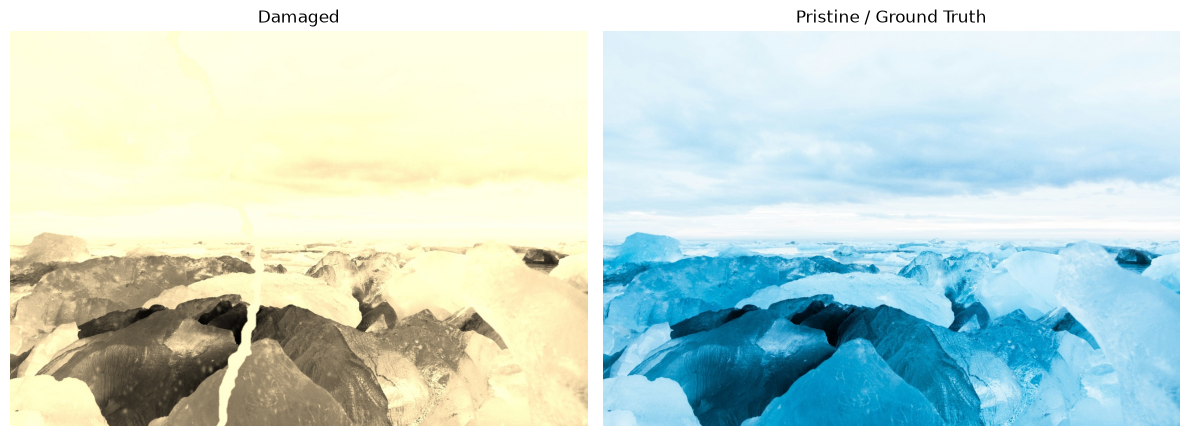

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(damaged)
axes[0].set_title("Damaged")
axes[0].axis("off")

axes[1].imshow(clean)
axes[1].set_title("Pristine / Ground Truth")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [8]:
from src.datasets.openphoto_dataset import OpenPhotoRestoreDataset

In [9]:
train_dataset = OpenPhotoRestoreDataset(
    dataset["train"],
    crop_size=256,
    training=True,
)

print("Number of training samples:", len(train_dataset))

Number of training samples: 4500


In [10]:
sample = train_dataset[0]

print("Keys:", sample.keys())
print("Damaged shape:", sample["damaged"].shape)
print("Clean shape:", sample["clean"].shape)
print("Damaged dtype:", sample["damaged"].dtype)
print("Clean dtype:", sample["clean"].dtype)

Keys: dict_keys(['damaged', 'clean'])
Damaged shape: torch.Size([3, 256, 256])
Clean shape: torch.Size([3, 256, 256])
Damaged dtype: torch.float32
Clean dtype: torch.float32


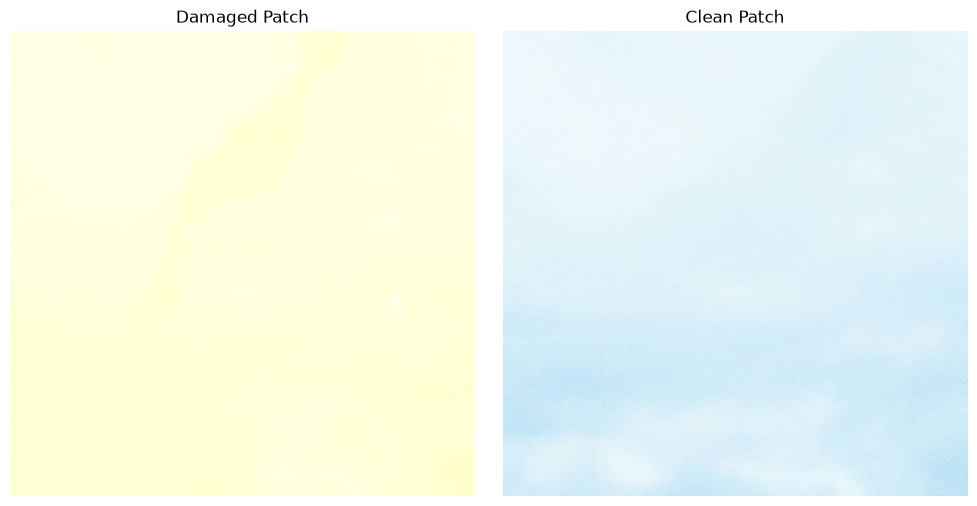

In [11]:
import matplotlib.pyplot as plt

damaged_tensor = sample["damaged"]
clean_tensor = sample["clean"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(damaged_tensor.permute(1, 2, 0))
axes[0].set_title("Damaged Patch")
axes[0].axis("off")

axes[1].imshow(clean_tensor.permute(1, 2, 0))
axes[1].set_title("Clean Patch")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
)

batch = next(iter(train_loader))

print("Damaged batch shape:", batch["damaged"].shape)
print("Clean batch shape:", batch["clean"].shape)

Damaged batch shape: torch.Size([4, 3, 256, 256])
Clean batch shape: torch.Size([4, 3, 256, 256])


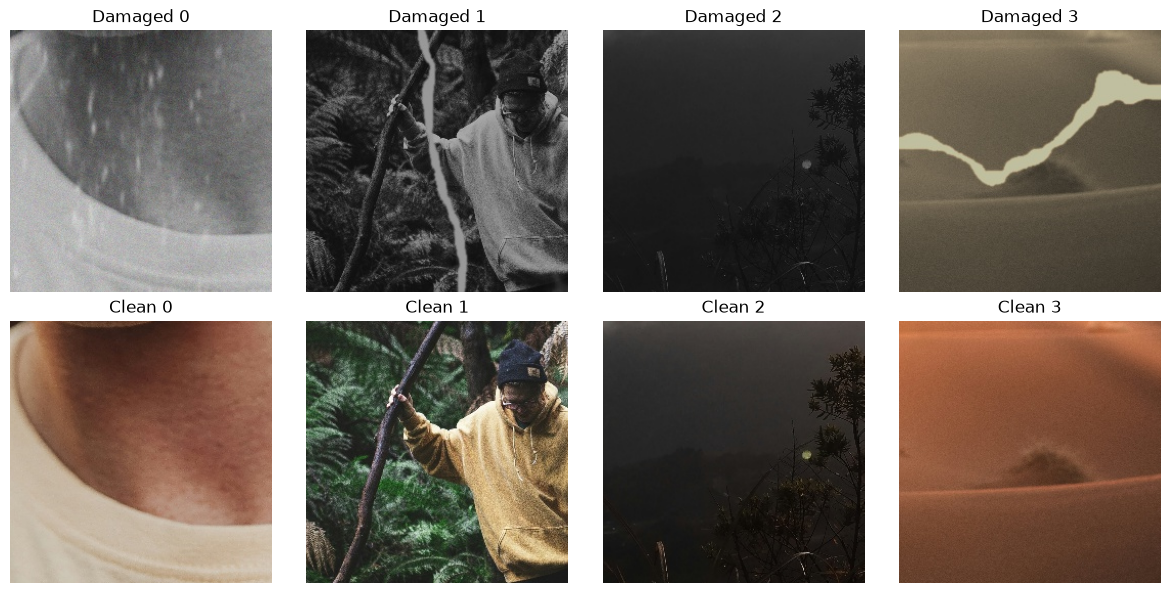

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    axes[0, i].imshow(batch["damaged"][i].permute(1, 2, 0))
    axes[0, i].set_title(f"Damaged {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(batch["clean"][i].permute(1, 2, 0))
    axes[1, i].set_title(f"Clean {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

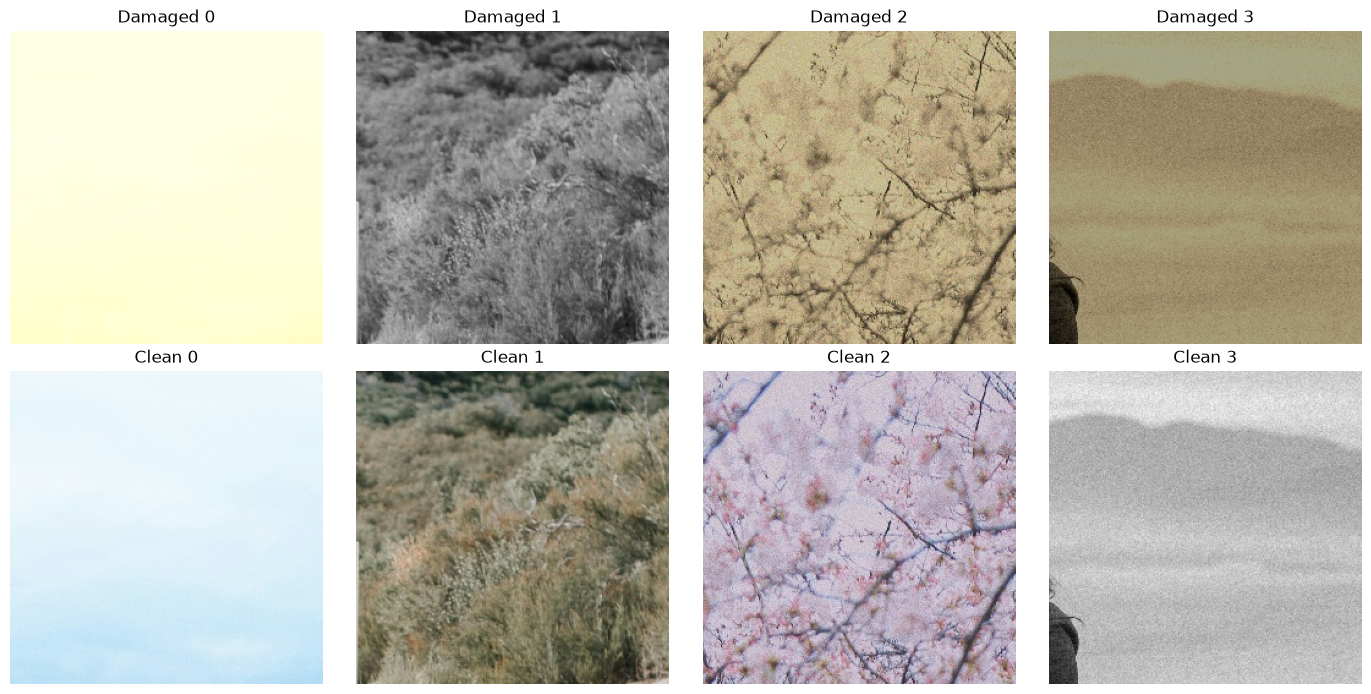

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i in range(4):
    sample = train_dataset[i]

    damaged = sample["damaged"]
    clean = sample["clean"]

    axes[0, i].imshow(damaged.permute(1, 2, 0).clamp(0, 1))
    axes[0, i].set_title(f"Damaged {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(clean.permute(1, 2, 0).clamp(0, 1))
    axes[1, i].set_title(f"Clean {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [15]:
print("Damaged range:", sample["damaged"].min().item(), sample["damaged"].max().item())
print("Clean range:", sample["clean"].min().item(), sample["clean"].max().item())


Damaged range: 0.0 0.7098039388656616
Clean range: 0.0 1.0


In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

batch = next(iter(train_loader))

print("Damaged batch shape:", batch["damaged"].shape)
print("Clean batch shape:", batch["clean"].shape)
print("Damaged dtype:", batch["damaged"].dtype)
print("Clean dtype:", batch["clean"].dtype)

Damaged batch shape: torch.Size([4, 3, 256, 256])
Clean batch shape: torch.Size([4, 3, 256, 256])
Damaged dtype: torch.float32
Clean dtype: torch.float32


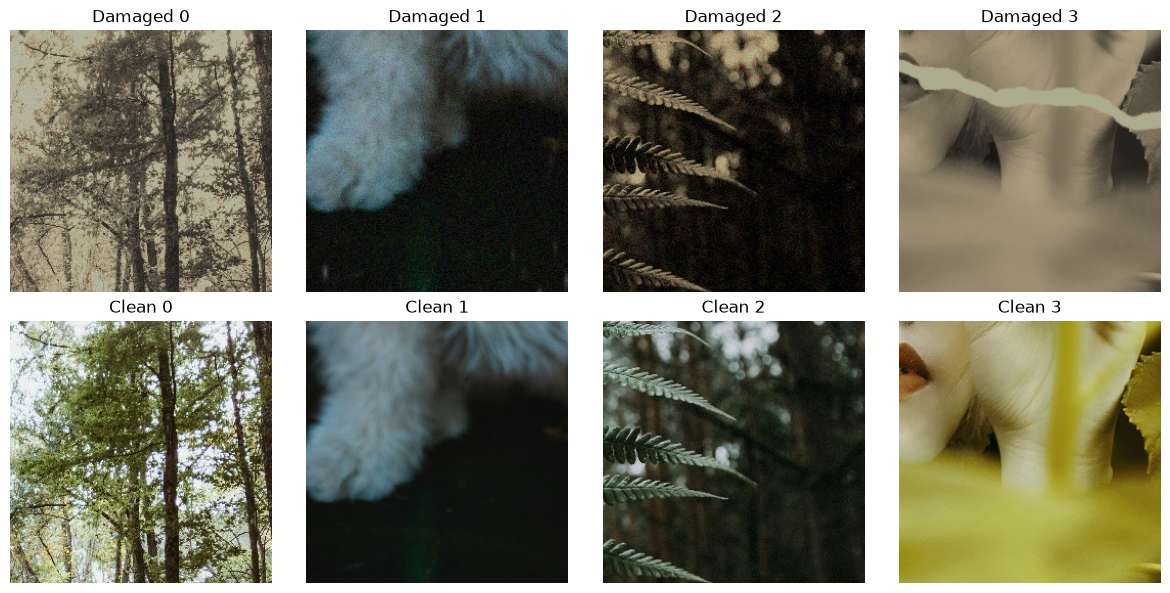

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    axes[0, i].imshow(batch["damaged"][i].permute(1, 2, 0))
    axes[0, i].set_title(f"Damaged {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(batch["clean"][i].permute(1, 2, 0))
    axes[1, i].set_title(f"Clean {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()